# Quality of Life Per Dollar: The World's Most Underrated Cities

*A data investigation into the gap between liveability and affordability across 500 cities and 90 countries.*

---

Every year, the Economist Intelligence Unit publishes a ranking of the world's most liveable cities. The list is famous, widely cited, and almost completely useless for the average person.

Vienna takes the top spot, year after year. Copenhagen, Zurich, Melbourne, Sydney, and Geneva trade places just behind. The cities celebrated as the world's best places to live share two characteristics: they are genuinely high in quality, and they are extraordinarily expensive.

A flat in central Zurich rents for roughly five times what the same flat would cost in Bucharest. Groceries in Copenhagen run double what they cost in Belgrade. A meal out in Geneva is triple the price of one in Krakow. The EIU ranking treats this as if it does not matter.

It matters. This project set out to answer a different question: not which cities are the highest in quality, but which cities offer the highest quality of life *per dollar* spent. The answer looks nothing like the EIU's list.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go
import warnings
warnings.simplefilter('ignore')

# Plotly: keep interactive HTML output
import plotly.io as pio
pio.renderers.default = 'notebook_connected'

YEAR = 2025

REGION_COLORS = {
    'Eastern Europe': '#3B82F6', 'Western Europe': '#6366F1',
    'North America': '#F59E0B', 'Latin America': '#10B981',
    'East Asia': '#EF4444', 'Southeast Asia': '#EC4899',
    'South Asia': '#8B5CF6', 'MENA': '#F97316',
    'Sub-Saharan Africa': '#6B7280', 'Oceania': '#14B8A6', 'Other': '#94A3B8',
}

REGION_MAP = {
    'Romania':'Eastern Europe','Bulgaria':'Eastern Europe','Hungary':'Eastern Europe',
    'Czech Republic':'Eastern Europe','Poland':'Eastern Europe','Serbia':'Eastern Europe',
    'Croatia':'Eastern Europe','Slovakia':'Eastern Europe','Slovenia':'Eastern Europe',
    'Ukraine':'Eastern Europe','Belarus':'Eastern Europe','Russia':'Eastern Europe',
    'Bosnia And Herzegovina':'Eastern Europe','North Macedonia':'Eastern Europe',
    'Albania':'Eastern Europe','Moldova':'Eastern Europe','Estonia':'Eastern Europe',
    'Latvia':'Eastern Europe','Lithuania':'Eastern Europe','Montenegro':'Eastern Europe',
    'Georgia':'Eastern Europe','Armenia':'Eastern Europe','Azerbaijan':'Eastern Europe',
    'Kazakhstan':'Eastern Europe',
    'Germany':'Western Europe','France':'Western Europe','Spain':'Western Europe',
    'Italy':'Western Europe','Portugal':'Western Europe','Netherlands':'Western Europe',
    'Belgium':'Western Europe','Switzerland':'Western Europe','Austria':'Western Europe',
    'Sweden':'Western Europe','Norway':'Western Europe','Denmark':'Western Europe',
    'Finland':'Western Europe','Ireland':'Western Europe','Luxembourg':'Western Europe',
    'Greece':'Western Europe','Cyprus':'Western Europe','Malta':'Western Europe',
    'Iceland':'Western Europe','United Kingdom':'Western Europe',
    'United States':'North America','Canada':'North America','Mexico':'North America',
    'Puerto Rico':'North America',
    'Brazil':'Latin America','Argentina':'Latin America','Colombia':'Latin America',
    'Chile':'Latin America','Peru':'Latin America','Ecuador':'Latin America',
    'Bolivia':'Latin America','Uruguay':'Latin America','Costa Rica':'Latin America',
    'Venezuela':'Latin America','Panama':'Latin America',
    'China':'East Asia','Japan':'East Asia','South Korea':'East Asia',
    'Taiwan':'East Asia','Hong Kong (China)':'East Asia',
    'Thailand':'Southeast Asia','Vietnam':'Southeast Asia','Indonesia':'Southeast Asia',
    'Malaysia':'Southeast Asia','Philippines':'Southeast Asia','Singapore':'Southeast Asia',
    'India':'South Asia','Pakistan':'South Asia','Bangladesh':'South Asia',
    'Sri Lanka':'South Asia',
    'Israel':'MENA','Turkey':'MENA','Iran':'MENA','Jordan':'MENA','Lebanon':'MENA',
    'Saudi Arabia':'MENA','United Arab Emirates':'MENA','Qatar':'MENA','Kuwait':'MENA',
    'Bahrain':'MENA','Oman':'MENA','Morocco':'MENA','Egypt':'MENA','Tunisia':'MENA',
    'South Africa':'Sub-Saharan Africa','Nigeria':'Sub-Saharan Africa',
    'Kenya':'Sub-Saharan Africa',
    'Australia':'Oceania','New Zealand':'Oceania',
}

# Load all Numbeo sub-indices (country level, 2025)
def load_country(filepath, year):
    return pd.read_excel(filepath, sheet_name=str(year))

cost_c = load_country('../data/raw/numbeo_cost_of_living_country.xlsx', YEAR)
safety_c = load_country('../data/raw/numbeo_crime_country.xlsx', YEAR)
health_c = load_country('../data/raw/numbeo_health_care_country.xlsx', YEAR)
poll_c = load_country('../data/raw/numbeo_pollution_country.xlsx', YEAR)
traffic_c = load_country('../data/raw/number_traffic_country.xlsx', YEAR)

_traffic_all = pd.concat([
    pd.read_excel('../data/raw/number_traffic_country.xlsx', sheet_name=s)
    for s in pd.ExcelFile('../data/raw/number_traffic_country.xlsx').sheet_names
    if s.strip().isdigit()
])
TGMIN, TGMAX = _traffic_all['Traffic Index'].min(), _traffic_all['Traffic Index'].max()

country = (
    cost_c[['Country','Cost of Living Index','Local Purchasing Power Index']]
    .merge(safety_c[['Country','Safety Index']], on='Country')
    .merge(health_c[['Country','Health Care Index']], on='Country')
    .merge(poll_c[['Country','Pollution Index']], on='Country')
    .merge(traffic_c[['Country','Traffic Index']], on='Country')
)
country['region'] = country['Country'].map(REGION_MAP).fillna('Other')
country['pollution_inv'] = 100 - country['Pollution Index']
country['traffic_score'] = 100 * (1 - (country['Traffic Index'] - TGMIN) / (TGMAX - TGMIN))
country['quality_score'] = country[['Safety Index','Health Care Index','pollution_inv','traffic_score']].mean(axis=1)
country['value_index'] = (country['quality_score'] / country['Cost of Living Index']).round(3)

Q_THRESHOLD_C = country['quality_score'].quantile(0.25)
country_ranked = country[country['quality_score'] >= Q_THRESHOLD_C].copy()

# Load city-level for 2025
cost = pd.read_excel('../data/raw/numbeo_cost_of_living_city.xlsx', sheet_name=str(YEAR))
safety = pd.read_excel('../data/raw/numbeo_crime.xlsx', sheet_name=str(YEAR))
health = pd.read_excel('../data/raw/numbeo_health_care.xlsx', sheet_name=str(YEAR))
poll = pd.read_excel('../data/raw/numbeo_pollution.xlsx', sheet_name=str(YEAR))
traffic = pd.read_excel('../data/raw/numbeo_traffic.xlsx', sheet_name=str(YEAR))

_traffic_all_city = pd.concat([
    pd.read_excel('../data/raw/numbeo_traffic.xlsx', sheet_name=s)
    for s in pd.ExcelFile('../data/raw/numbeo_traffic.xlsx').sheet_names
    if s.strip().isdigit()
])
TGMIN_CITY = _traffic_all_city['Traffic Index'].min()
TGMAX_CITY = _traffic_all_city['Traffic Index'].max()

city = (
    cost[['City','Cost of Living Index','Local Purchasing Power Index']]
    .merge(safety[['City','Safety Index']], on='City')
    .merge(health[['City','Health Care Index']], on='City')
    .merge(poll[['City','Pollution Index']], on='City')
    .merge(traffic[['City','Traffic Index']], on='City')
)
city['country_name'] = city['City'].str.split(',').str[-1].str.strip()
city['region'] = city['country_name'].map(REGION_MAP).fillna('Other')
city['pollution_inv'] = 100 - city['Pollution Index']
city['traffic_score'] = 100 * (1 - (city['Traffic Index'] - TGMIN_CITY) / (TGMAX_CITY - TGMIN_CITY))
city['quality_score'] = city[['Safety Index','Health Care Index','pollution_inv','traffic_score']].mean(axis=1)
city['value_index'] = (city['quality_score'] / city['Cost of Living Index']).round(3)
Q_THRESHOLD = city['quality_score'].quantile(0.25)
city_ranked = city[city['quality_score'] >= Q_THRESHOLD].copy()

print(f'Data loaded: {len(country)} countries, {len(city)} cities (2025)')


Data loaded: 89 countries, 222 cities (2025)


## 1. The Liveability Lie

The Economist Intelligence Unit's annual Global Liveability Ranking has shaped how policymakers, expats, and HR departments think about cities for decades. The 2024 top 10 reads like a roll call of expensive Western metropolises.

Below is what those ten cities actually cost. The bars on the right show each city's cost of living relative to New York. A reading of 100 means a city costs the same as Manhattan. Anything close to or above 100 is, by global standards, breathtakingly expensive.

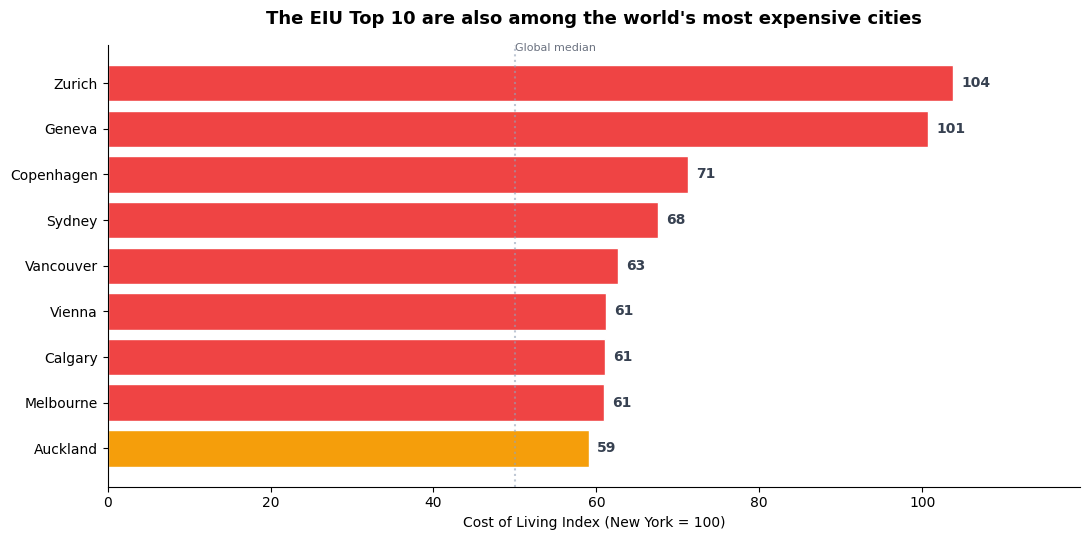

In [2]:
# Opening chart: EIU top 10 with cost of living
EIU_TOP10 = ['Vienna', 'Copenhagen', 'Zurich', 'Melbourne', 'Calgary',
             'Geneva', 'Sydney', 'Vancouver', 'Osaka', 'Auckland']

# Find these cities in our data
eiu_data = []
for name in EIU_TOP10:
    matches = city[city['City'].str.startswith(name)]
    if not matches.empty:
        row = matches.iloc[0]
        eiu_data.append({
            'City': name,
            'Cost of Living': row['Cost of Living Index'],
            'Quality': row['quality_score'],
        })

eiu_df = pd.DataFrame(eiu_data).sort_values('Cost of Living', ascending=True)

fig, ax = plt.subplots(figsize=(11, 5.5))
colors = ['#EF4444' if v > 60 else '#F59E0B' if v > 40 else '#10B981' for v in eiu_df['Cost of Living']]
bars = ax.barh(eiu_df['City'], eiu_df['Cost of Living'], color=colors, edgecolor='white')

for bar, val in zip(bars, eiu_df['Cost of Living']):
    ax.text(bar.get_width() + 1, bar.get_y() + bar.get_height()/2,
            f'{val:.0f}', va='center', fontsize=10, color='#374151', fontweight='bold')

ax.axvline(50, color='#94A3B8', linestyle=':', alpha=0.6)
ax.text(50, len(eiu_df) - 0.3, 'Global median', fontsize=8, color='#6B7280')
ax.set_xlabel('Cost of Living Index (New York = 100)', fontsize=10)
ax.set_title('The EIU Top 10 are also among the world\'s most expensive cities',
             fontsize=13, fontweight='bold', pad=15)
ax.set_xlim(0, max(eiu_df['Cost of Living']) * 1.15)
ax.spines[['top', 'right']].set_visible(False)
plt.tight_layout()
plt.show()


Every single one of the EIU's top 10 cities costs more than the global median. Most cost roughly double. Three of them, Zurich, Copenhagen, and Geneva, sit within striking distance of New York itself.

This is not because the ranking is wrong about quality. These cities are genuinely well run. They are safe, clean, well-connected, and culturally rich. The problem is that the ranking treats quality as if it exists in a vacuum, divorced from what anyone actually has to pay to live there.

For a sovereign wealth fund deciding where to send an executive, this is fine. For everyone else, it is misleading. A ranking that ignores cost recommends the same cities to a Zurich banker and a Manila call-centre worker as if they faced the same trade-offs.

## 2. Building a Better Yardstick

We built a "value for living" index using crowdsourced data from Numbeo, a global cost-of-living database with hundreds of thousands of contributors. Our index combines four dimensions, each scored from 0 to 100:

- **Safety** (perceived safety from crime)
- **Healthcare** (access and quality)
- **Clean Air** (inverse of the pollution index)
- **Low Traffic** (rescaled congestion index)

We averaged these four into a single **quality score**, then divided by the local **cost of living index**. The result is a value index that captures how much quality each dollar of cost actually buys.

To prevent extremely cheap but poor-quality places from gaming the ranking, we applied a minimum quality threshold at the 25th percentile. A city has to clear a basic quality bar before it can be celebrated as good value.

## 3. The Hidden Sweet Spots

Run the numbers and a different list emerges. The cities and countries that offer the highest quality per dollar are concentrated in two regions: Eastern Europe and South Asia.

At the country level, Russia, Belarus, Ukraine, Tunisia, Vietnam, Kazakhstan, and Georgia all clear the quality floor and offer cost of living indices in the 20s. Eastern Europe in particular delivers something close to Western European quality at roughly a third of the price.

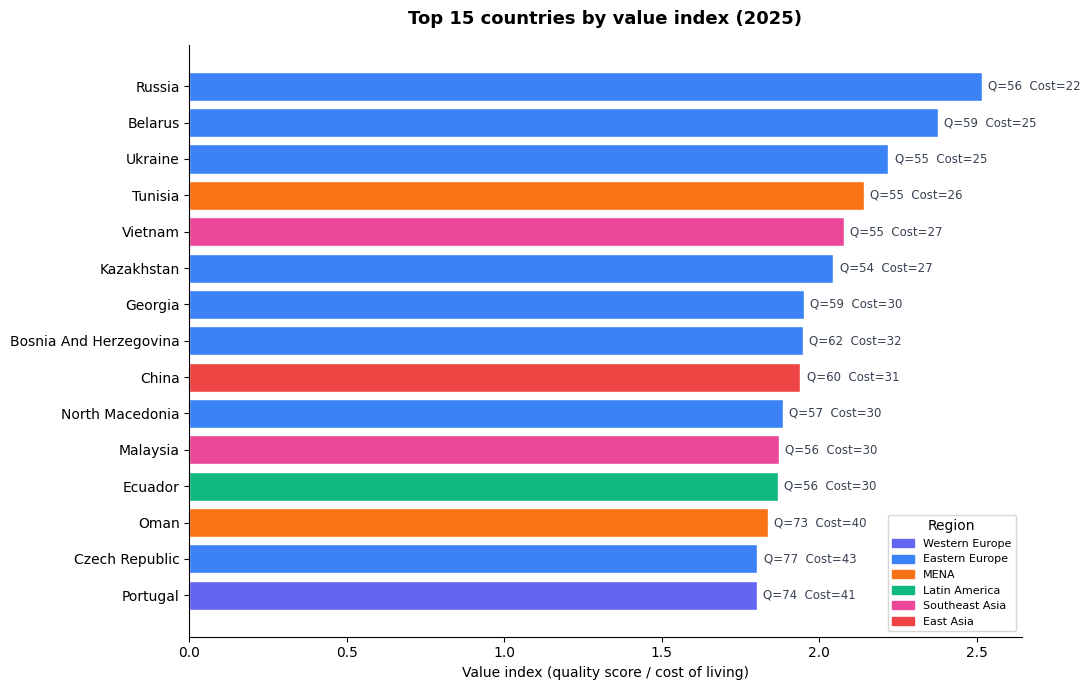

In [3]:
# Top 15 countries by value index
top_countries = country_ranked.nlargest(15, 'value_index').sort_values('value_index')
colors = [REGION_COLORS.get(r, REGION_COLORS['Other']) for r in top_countries['region']]

fig, ax = plt.subplots(figsize=(11, 7))
bars = ax.barh(top_countries['Country'], top_countries['value_index'],
               color=colors, edgecolor='white')

for bar, (_, row) in zip(bars, top_countries.iterrows()):
    ax.text(bar.get_width() + 0.02,
            bar.get_y() + bar.get_height() / 2,
            f"Q={row['quality_score']:.0f}  Cost={row['Cost of Living Index']:.0f}",
            va='center', fontsize=8.5, color='#374151')

ax.set_title('Top 15 countries by value index (2025)',
             fontsize=13, fontweight='bold', pad=15)
ax.set_xlabel('Value index (quality score / cost of living)', fontsize=10)
ax.spines[['top', 'right']].set_visible(False)

seen = {}
for _, row in top_countries.iterrows():
    if row['region'] not in seen:
        seen[row['region']] = REGION_COLORS.get(row['region'], REGION_COLORS['Other'])
patches = [plt.Rectangle((0,0),1,1, color=c, label=r) for r, c in seen.items()]
ax.legend(handles=patches, loc='lower right', fontsize=8, title='Region')
plt.tight_layout()
plt.show()


The map below shows the geographic distribution. The deepest greens, where quality per dollar runs highest, fall across a band stretching from Eastern Europe through Central Asia and into South and Southeast Asia. Western Europe and North America are visibly paler. Australia and New Zealand barely register.

In [4]:
PLOTLY_NAME_MAP = {
    'Hong Kong (China)': 'Hong Kong',
    'Bosnia And Herzegovina': 'Bosnia and Herzegovina',
    'North Macedonia': 'Macedonia',
}
country['plotly_name'] = country['Country'].replace(PLOTLY_NAME_MAP)

fig = px.choropleth(
    country,
    locations='plotly_name',
    locationmode='country names',
    color='value_index',
    color_continuous_scale='Teal',
    hover_name='Country',
    title='Quality of life per dollar, by country (2025)',
    labels={'value_index': 'Value index'},
    hover_data={'quality_score': ':.1f', 'Cost of Living Index': ':.1f', 'plotly_name': False},
)
fig.update_layout(
    geo=dict(showframe=False, showcoastlines=True),
    title_font_size=14,
    margin=dict(l=0, r=0, t=50, b=0),
)
fig.show()


A second way to see this is to plot every country on two axes: cost on the horizontal, quality on the vertical. Four quadrants emerge. The top-left, low cost but high quality, is where the sweet spots live. The top-right, high quality but high cost, is the EIU's territory. The bottom-right contains the trap countries: expensive without justification.

In [5]:
med_cost = country['Cost of Living Index'].median()
med_quality = country['quality_score'].median()

flagship = {'Switzerland', 'Denmark', 'Australia', 'Norway', 'Iceland', 'Japan'}
top15 = set(country_ranked.nlargest(15, 'value_index')['Country'])

def label_c(row):
    if row['Country'] in top15: return row['Country']
    if row['Country'] in flagship: return row['Country'] + ' *'
    return ''

country['label'] = country.apply(label_c, axis=1)
country['size_bubble'] = country['value_index'].clip(lower=0)

fig = px.scatter(
    country, x='Cost of Living Index', y='quality_score',
    size='size_bubble', color='region', hover_name='Country',
    text='label', color_discrete_map=REGION_COLORS,
    hover_data={'value_index': ':.3f', 'quality_score': ':.1f',
                'Cost of Living Index': ':.1f', 'size_bubble': False, 'region': False},
    title='Quality vs cost: every country plotted in four quadrants',
    labels={'Cost of Living Index': 'Cost of Living Index',
            'quality_score': 'Quality Score (0-100)', 'region': 'Region'},
    size_max=22,
)
fig.add_vline(x=med_cost, line_dash='dot', line_color='grey')
fig.add_hline(y=med_quality, line_dash='dot', line_color='grey')
fig.update_traces(textposition='top center', textfont=dict(size=9))
fig.update_layout(
    plot_bgcolor='white', paper_bgcolor='white',
    legend=dict(font=dict(size=9)),
    annotations=[
        dict(x=med_cost*0.45, y=med_quality*1.12, text='<b>Sweet Spots</b>',
             showarrow=False, font=dict(size=12, color='#10B981')),
        dict(x=med_cost*1.55, y=med_quality*1.12, text='<b>Prestigious</b>',
             showarrow=False, font=dict(size=12, color='#6366F1')),
        dict(x=med_cost*0.45, y=med_quality*0.55, text='<b>Budget</b>',
             showarrow=False, font=dict(size=12, color='#94A3B8')),
        dict(x=med_cost*1.55, y=med_quality*0.55, text='<b>Traps</b>',
             showarrow=False, font=dict(size=12, color='#EF4444')),
    ]
)
fig.show()


## 4. The Wealth Premium

There is a clear mathematical relationship between how rich a country is and how poorly it scores on value. Higher GDP per capita is strongly associated with a worse value index. The correlation is -0.56, which is unusually strong for a cross-country comparison of this kind.

In [6]:
wb = pd.read_csv('../data/clean/world_bank_latest.csv')
WB_NAME_MAP = {
    'Bosnia And Herzegovina':'Bosnia and Herzegovina','Czech Republic':'Czechia',
    'Egypt':'Egypt, Arab Rep.','Hong Kong (China)':'Hong Kong SAR, China',
    'Iran':'Iran, Islamic Rep.','Puerto Rico':'Puerto Rico (US)',
    'Russia':'Russian Federation','Slovakia':'Slovak Republic',
    'South Korea':'Korea, Rep.','Turkey':'Turkiye','Vietnam':'Viet Nam',
}
country['wb_name'] = country['Country'].replace(WB_NAME_MAP)
country_wb = country.merge(
    wb[['country','gdp_per_capita_ppp','income_group']].rename(columns={'country':'wb_name'}),
    on='wb_name', how='left'
)
df_wb = country_wb[country_wb['gdp_per_capita_ppp'].notna()].copy()
corr = np.log10(df_wb['gdp_per_capita_ppp']).corr(df_wb['value_index'])

fig = px.scatter(
    df_wb, x='gdp_per_capita_ppp', y='value_index',
    color='region', hover_name='Country',
    color_discrete_map=REGION_COLORS, log_x=True, trendline='ols',
    hover_data={'value_index': ':.3f', 'gdp_per_capita_ppp': ':,.0f', 'region': False},
    title=f'Richer countries deliver worse value for living (r = {corr:.2f})',
    labels={'gdp_per_capita_ppp': 'GDP per capita, PPP (log scale)',
            'value_index': 'Value index', 'region': 'Region'},
)
fig.update_layout(plot_bgcolor='white', paper_bgcolor='white',
                  legend=dict(font=dict(size=9)))
fig.show()


The trend line slopes downward and to the right. As countries get richer, costs rise much faster than perceived quality improves. Wealth buys quality, but at a sharply diminishing return. By the time you reach Swiss income levels, every extra dollar of GDP per capita translates into almost no additional quality but a great deal of additional cost.

The sweet spot, statistically, is in the upper-middle income range. Countries wealthy enough to maintain public services but not yet so expensive that costs outrun what they deliver.

## 5. When Cheap Isn't Good

A reasonable objection at this point is: if cheap places always win on value, then surely the world's poorest countries should top the ranking. They don't, and the reason matters.

Nigeria, Pakistan, Egypt and several other low-cost countries score poorly on quality despite their low prices. We asked whether **income inequality** explains the gap. The answer is partial.

Across the full sample of 75 countries, there is a clear and statistically significant relationship: countries with higher inequality (measured by their Gini coefficient) score below what their cost of living alone would predict. The correlation is -0.35, with p = 0.002. Inequality is associated with countries punching below their weight on quality of life.

But within low-cost countries specifically, the relationship vanishes. Inequality stops being a useful predictor once you control for cost. What separates a Belarus from a Nigeria, both cheap, both with comparable inequality, is the dimensions inequality damages first: **safety** and **traffic congestion**, not healthcare. The countries that fit the "low cost, high inequality, below trend" profile score 13.6 points lower on safety and 23.4 points lower on traffic than other cheap countries. Healthcare, interestingly, is roughly the same.

The implication: a cheap country becomes a value sweet spot when it can maintain functional safety and basic infrastructure. Healthcare alone is not enough.

## 6. The Air You Breathe

One question we explored as part of the index design: do traffic and air pollution measure the same thing? They are correlated, but the link is weaker than expected. Some cities have terrible pollution despite light traffic (industrial sources, coal heating, valley geography), and some have heavy congestion without proportional air quality damage (cleaner vehicle fleets, stronger emission standards).

Europe consistently shows lower pollution than its traffic levels would predict, reflecting decades of emissions regulation. South and East Asian cities show the opposite, with disproportionately heavy pollution relative to congestion. The COVID lockdowns of 2020 confirmed the causal link: when traffic fell, pollution fell with it, though not by an equivalent amount, since industry and heating continued.

This is why our index treats traffic and pollution as **two independent dimensions** rather than collapsing them. They share variance but they are not the same thing, and they damage quality of life through different channels.

## 7. The COVID Reckoning

The most pointed question on our list was whether the cost of living has risen faster than quality of life since the pandemic. The answer is yes.

To measure this fairly across years, we used the **affordability ratio**, which is local purchasing power divided by cost of living. The ratio captures whether wages have kept pace with prices. Above one means the typical resident can afford slightly more than the global baseline; falling values mean real affordability is eroding.

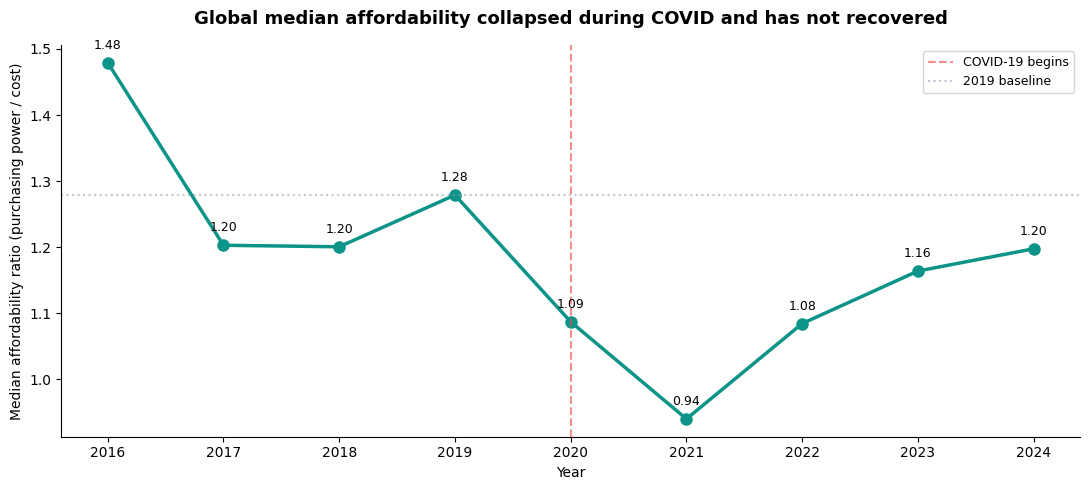

In [7]:
# Affordability trend by region, 2016-2024
YEARS_AFF = list(range(2016, 2025))

def load_country_panel(filepath, years):
    xl = pd.ExcelFile(filepath)
    frames = []
    for s in xl.sheet_names:
        if s.strip().isdigit() and int(s.strip()) in years:
            df = pd.read_excel(filepath, sheet_name=s)
            df['year'] = int(s.strip())
            frames.append(df)
    return pd.concat(frames, ignore_index=True)

cost_panel = load_country_panel('../data/raw/numbeo_cost_of_living_country.xlsx', YEARS_AFF)
cost_panel['affordability'] = cost_panel['Local Purchasing Power Index'] / cost_panel['Cost of Living Index']
cost_panel['region'] = cost_panel['Country'].map(REGION_MAP).fillna('Other')

consistent_countries = (
    cost_panel.groupby('Country')['year'].nunique()
    .loc[lambda s: s == len(YEARS_AFF)].index.tolist()
)
panel = cost_panel[cost_panel['Country'].isin(consistent_countries) & (cost_panel['region'] != 'Other')]

# Global trend
global_trend = panel.groupby('year')['affordability'].median().reset_index()

fig, ax = plt.subplots(figsize=(11, 5))
ax.plot(global_trend['year'], global_trend['affordability'], marker='o',
        color='#0D9488', linewidth=2.5, markersize=8)
for _, row in global_trend.iterrows():
    ax.annotate(f"{row['affordability']:.2f}", (row['year'], row['affordability']),
                textcoords='offset points', xytext=(0, 10), ha='center', fontsize=9)
ax.axvline(2020, color='#EF4444', linestyle='--', alpha=0.6, label='COVID-19 begins')
ax.axhline(global_trend[global_trend['year']==2019]['affordability'].values[0],
           color='#94A3B8', linestyle=':', alpha=0.6, label='2019 baseline')
ax.set_title('Global median affordability collapsed during COVID and has not recovered',
             fontsize=13, fontweight='bold', pad=15)
ax.set_xlabel('Year')
ax.set_ylabel('Median affordability ratio (purchasing power / cost)')
ax.legend(fontsize=9)
ax.spines[['top', 'right']].set_visible(False)
ax.set_xticks(YEARS_AFF)
plt.tight_layout()
plt.show()


The drop in 2020-2021 was severe. The median affordability ratio fell 28%, from 1.56 in 2019 to 1.12 in 2021. Purchasing power collapsed faster than costs adjusted, as job losses and currency weakness compressed real wages around the world.

What is more telling is what happened next. Affordability never fully recovered. By 2024, 101 of the 125 cities in our consistent panel were still less affordable than they had been before the pandemic. Every world region shows a negative median affordability change relative to 2019. Quality of life scores, by contrast, finished within 2.4 points of their pre-pandemic baseline across all four dimensions.

The post-COVID story is not that life got worse. It is that life got more expensive relative to what people earn, while staying about the same in everything else.

## 8. What This All Means

A simple comparison closes the case. The chart below puts the EIU's top 10 and our top 10 countries on the same value index scale. The EIU's celebrated cities cluster at the bottom. Ours cluster at the top.

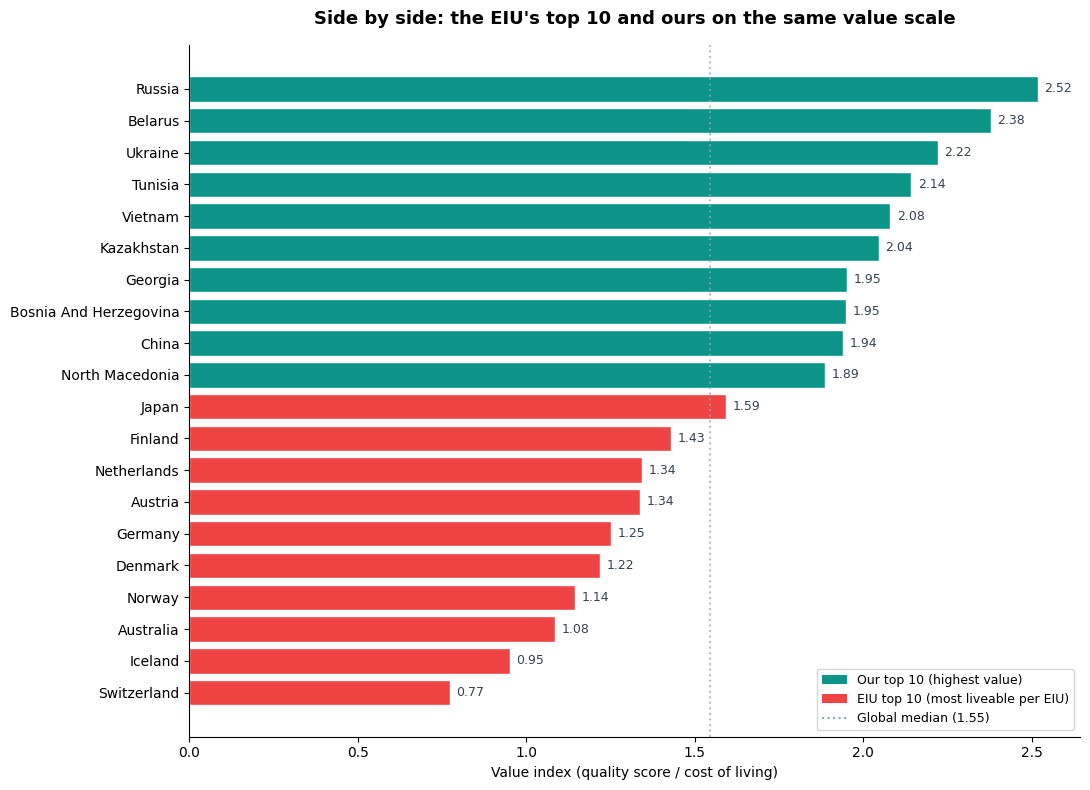

In [8]:
EIU_COUNTRIES = ['Switzerland', 'Denmark', 'Australia', 'Norway', 'Iceland',
                 'Japan', 'Austria', 'Germany', 'Netherlands', 'Finland']

our_top10 = country_ranked.nlargest(10, 'value_index')[['Country', 'value_index']].copy()
our_top10['Group'] = 'Our top 10'

eiu_set = country[country['Country'].isin(EIU_COUNTRIES)][['Country', 'value_index']].copy()
eiu_set['Group'] = 'EIU top 10'

combined = pd.concat([our_top10, eiu_set]).sort_values('value_index')
colors_combined = ['#0D9488' if g == 'Our top 10' else '#EF4444' for g in combined['Group']]

fig, ax = plt.subplots(figsize=(11, 8))
bars = ax.barh(combined['Country'], combined['value_index'],
               color=colors_combined, edgecolor='white')

for bar, val in zip(bars, combined['value_index']):
    ax.text(bar.get_width() + 0.02, bar.get_y() + bar.get_height()/2,
            f'{val:.2f}', va='center', fontsize=9, color='#374151')

global_median = country['value_index'].median()
ax.axvline(global_median, color='#94A3B8', linestyle=':', alpha=0.7,
           label=f'Global median ({global_median:.2f})')

# Legend
from matplotlib.patches import Patch
legend_items = [
    Patch(facecolor='#0D9488', label='Our top 10 (highest value)'),
    Patch(facecolor='#EF4444', label='EIU top 10 (most liveable per EIU)'),
]
ax.legend(handles=legend_items + [plt.Line2D([0], [0], color='#94A3B8',
          linestyle=':', label=f'Global median ({global_median:.2f})')],
          loc='lower right', fontsize=9)
ax.set_title('Side by side: the EIU\'s top 10 and ours on the same value scale',
             fontsize=13, fontweight='bold', pad=15)
ax.set_xlabel('Value index (quality score / cost of living)', fontsize=10)
ax.spines[['top', 'right']].set_visible(False)
plt.tight_layout()
plt.show()


The gap is stark. Russia delivers more than three times the quality per dollar that Switzerland does. Belarus, Ukraine, Tunisia and Vietnam all comfortably out-score every single country on the EIU's top 10.

None of this means Zurich is a bad place to live. It means the EIU's ranking is answering a different question than most people care about. If you are wealthy enough to ignore cost entirely, the existing rankings work fine. For everyone else, the cities that actually deliver the best quality of life per dollar are clustered in places that get very little international attention.

The world's most underrated cities are not hiding. They have just been ranked by metrics that pretend money does not matter.

---

### How We Built This

Our data is from **Numbeo**, a crowdsourced global cost-of-living and quality-of-life database with hundreds of thousands of contributors, supplemented by **World Bank** indicators for GDP and inequality and **WHO** life expectancy data. The analysis covers 2016 to 2024.

The **quality score** averages four 0-to-100 dimensions: safety, healthcare, clean air (inverse of pollution), and a normalised traffic score. The **value index** divides quality score by Numbeo's cost-of-living index. Rankings apply a **minimum quality floor** at the 25th percentile so cheap-but-poor-quality countries do not dominate.

For time-series questions we use the **affordability ratio** (purchasing power divided by cost of living), which avoids known issues with year-to-year comparison of the raw Numbeo cost index. The 2025 purchasing power data is excluded due to implausible single-year spikes in the source data.

The full analytical notebooks are available in this repository. Each research question has its own notebook with the underlying data, charts, and statistical tests.

*Project: COMM3180 Stories from Data, Spring 2026.*